# 🚢 Titanic — Полный ML-анализ
**Датасет:** Titanic.csv  
**Цель:** предсказать выживаемость пассажиров
---

## 0. Импорты и настройки

In [1]:
from google.colab import files
uploaded = files.upload()
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)

df_raw = pd.read_csv('Titanic.csv')
df = df_raw.copy()
print(df.shape)
df.head(3)


Saving Titanic.csv to Titanic.csv
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


<a id='eda'></a>
# 1. EDA — Исследовательский анализ данных

### 1.1 Базовые сведения о датасете

In [2]:
print("=== Форма датасета ===")
print(df.shape)
print("\n=== Типы данных ===")
print(df.dtypes)
print("\n=== Пропущенные значения ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct%': missing_pct})[missing > 0])


=== Форма датасета ===
(891, 12)

=== Типы данных ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Пропущенные значения ===
          count   pct%
Age         177  19.87
Cabin       687  77.10
Embarked      2   0.22


In [3]:
df.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### 1.2 Распределение целевой переменной

> **Комментарий:** Проверим баланс классов — это важно для выбора метрики и стратегии обучения.

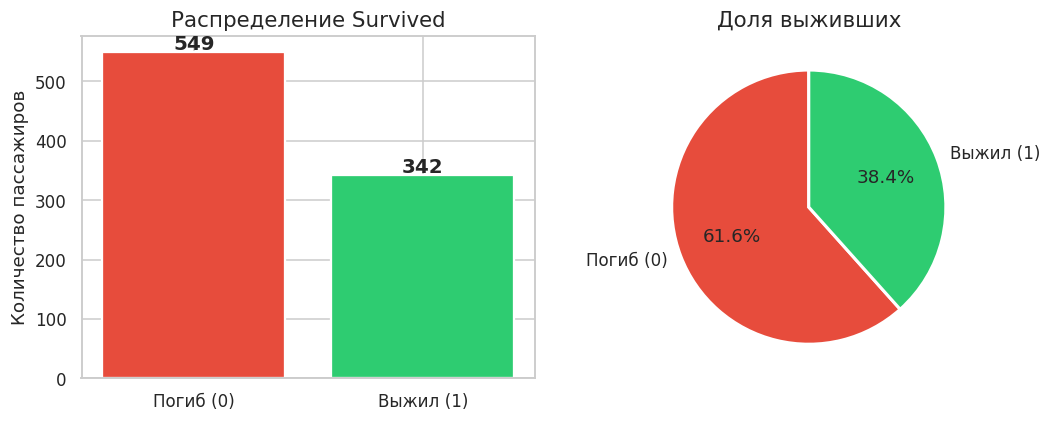

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Survived'].value_counts()
axes[0].bar(['Погиб (0)', 'Выжил (1)'], counts.values,
            color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Распределение Survived', fontsize=14)
axes[0].set_ylabel('Количество пассажиров')

axes[1].pie(counts.values, labels=['Погиб (0)', 'Выжил (1)'],
            colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Доля выживших', fontsize=14)

plt.tight_layout()
plt.savefig('eda_target.png', bbox_inches='tight')
plt.show()
print()


> **Вывод:** Классы несбалансированы — ~61.6% погибли, ~38.4% выжили. Для оценки моделей будем использовать **ROC-AUC** вместе с Accuracy.

### 1.3 Распределение числовых признаков

> **Комментарий:** Построим гистограммы числовых признаков с разбивкой по классу выживаемости.

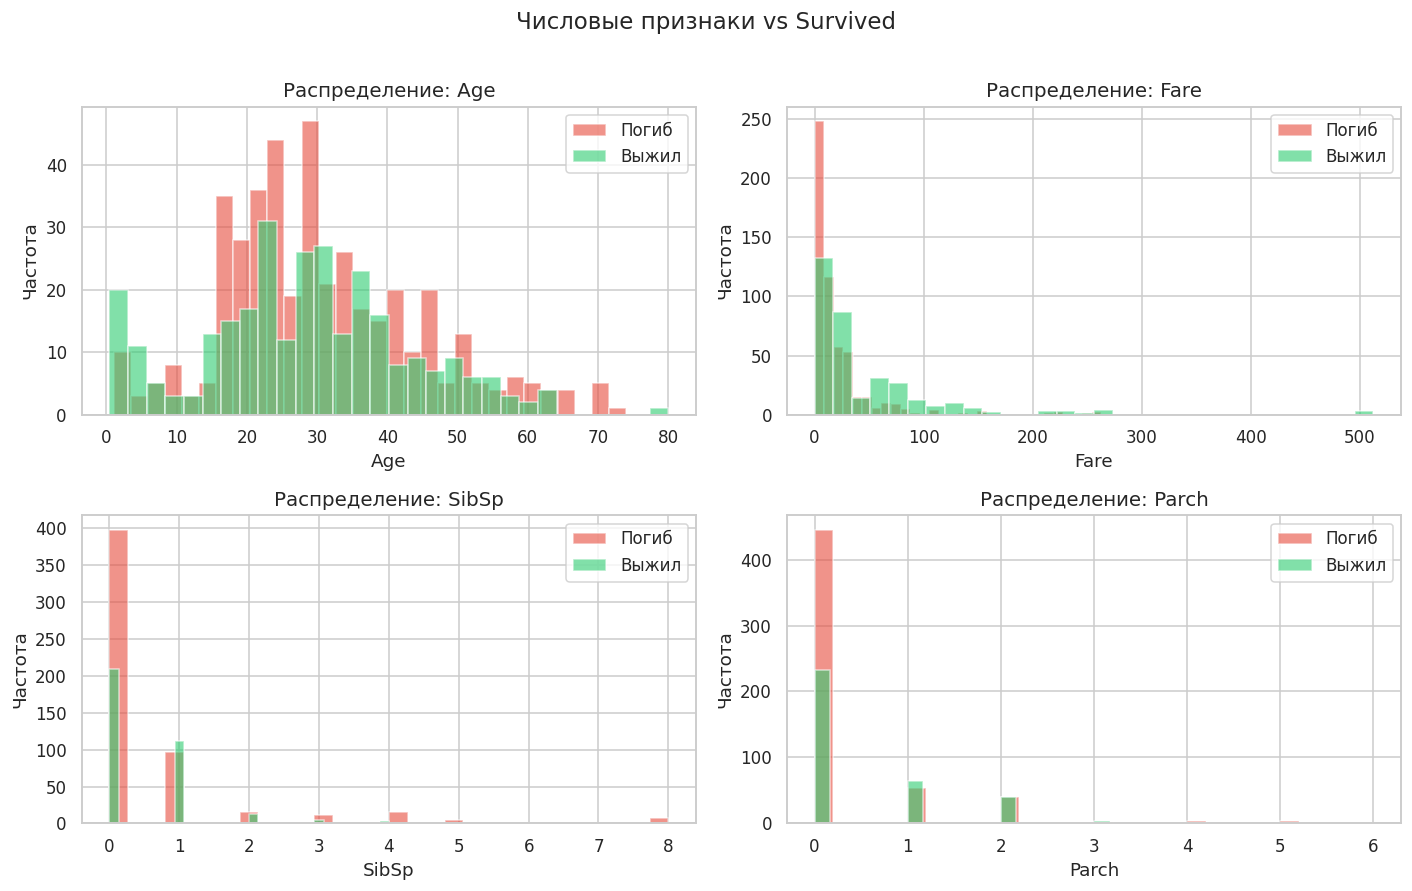

In [5]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for label, color, name in [(0, '#E74C3C', 'Погиб'), (1, '#2ECC71', 'Выжил')]:
        data = df[df['Survived'] == label][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(f'Распределение: {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].legend()
plt.suptitle('Числовые признаки vs Survived', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_num_dist.png', bbox_inches='tight')
plt.show()


> **Вывод:**
> - **Age**: молодые пассажиры чаще выживали; пик смертности — мужчины 20–40 лет.
> - **Fare**: высокая цена билета коррелирует с выживаемостью (богатые пассажиры 1-го класса).
> - **SibSp / Parch**: пассажиры без родственников или с 1–2 родственниками выживали лучше, чем большие семьи.


### 1.4 Категориальные признаки vs Survived

> **Комментарий:** Сравним долю выживших в разных категориях.

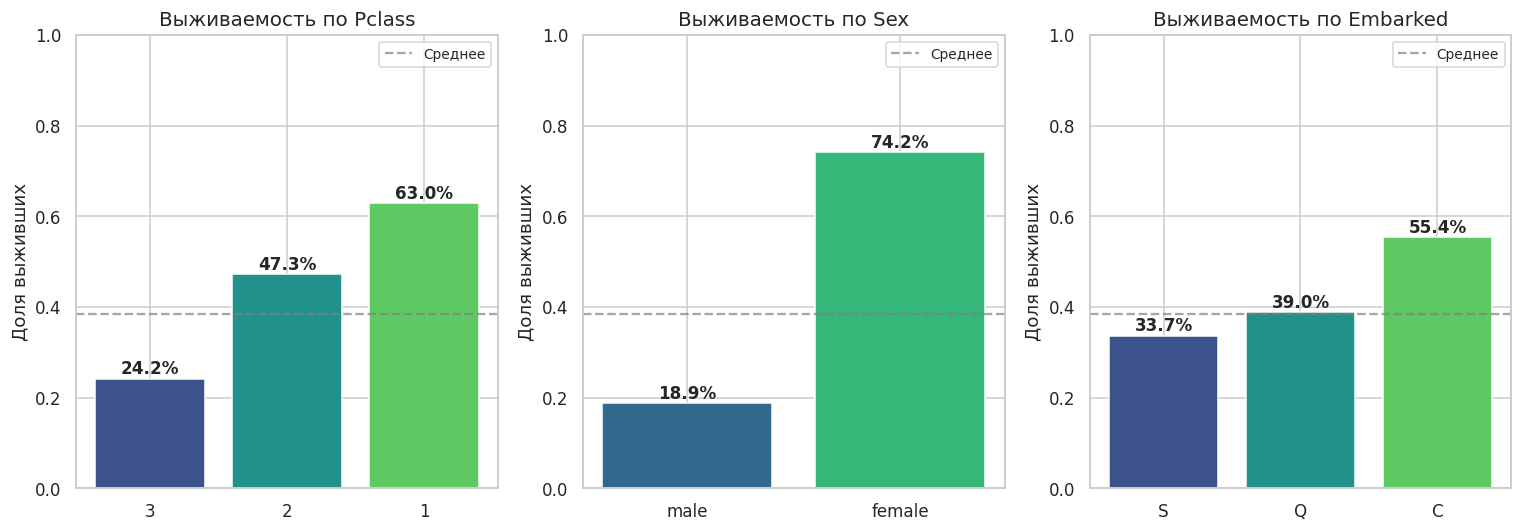

In [6]:
cat_cols = ['Pclass', 'Sex', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(cat_cols):
    surv_rate = df.groupby(col)['Survived'].mean().sort_values()
    bars = axes[i].bar(surv_rate.index.astype(str), surv_rate.values,
                       color=sns.color_palette('viridis', len(surv_rate)), edgecolor='white')
    for bar, val in zip(bars, surv_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
    axes[i].set_title(f'Выживаемость по {col}', fontsize=13)
    axes[i].set_ylabel('Доля выживших')
    axes[i].set_ylim(0, 1)
    axes[i].axhline(df['Survived'].mean(), ls='--', color='gray', alpha=0.7, label='Среднее')
    axes[i].legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda_cat.png', bbox_inches='tight')
plt.show()


> **Вывод:**
> - **Pclass**: пассажиры 1-го класса выживали в ~63%, 3-го — лишь ~24%.
> - **Sex**: женщины выживали в ~74%, мужчины — лишь ~19% (правило «женщины и дети первыми»).
> - **Embarked**: порт посадки C (Шербур) даёт наибольший процент выживших (~55%), вероятно из-за доли пассажиров 1-го класса.


### 1.5 Матрица корреляций (числовые признаки с Survived)

> **Комментарий:** Pearson-корреляция числовых признаков с таргетом.

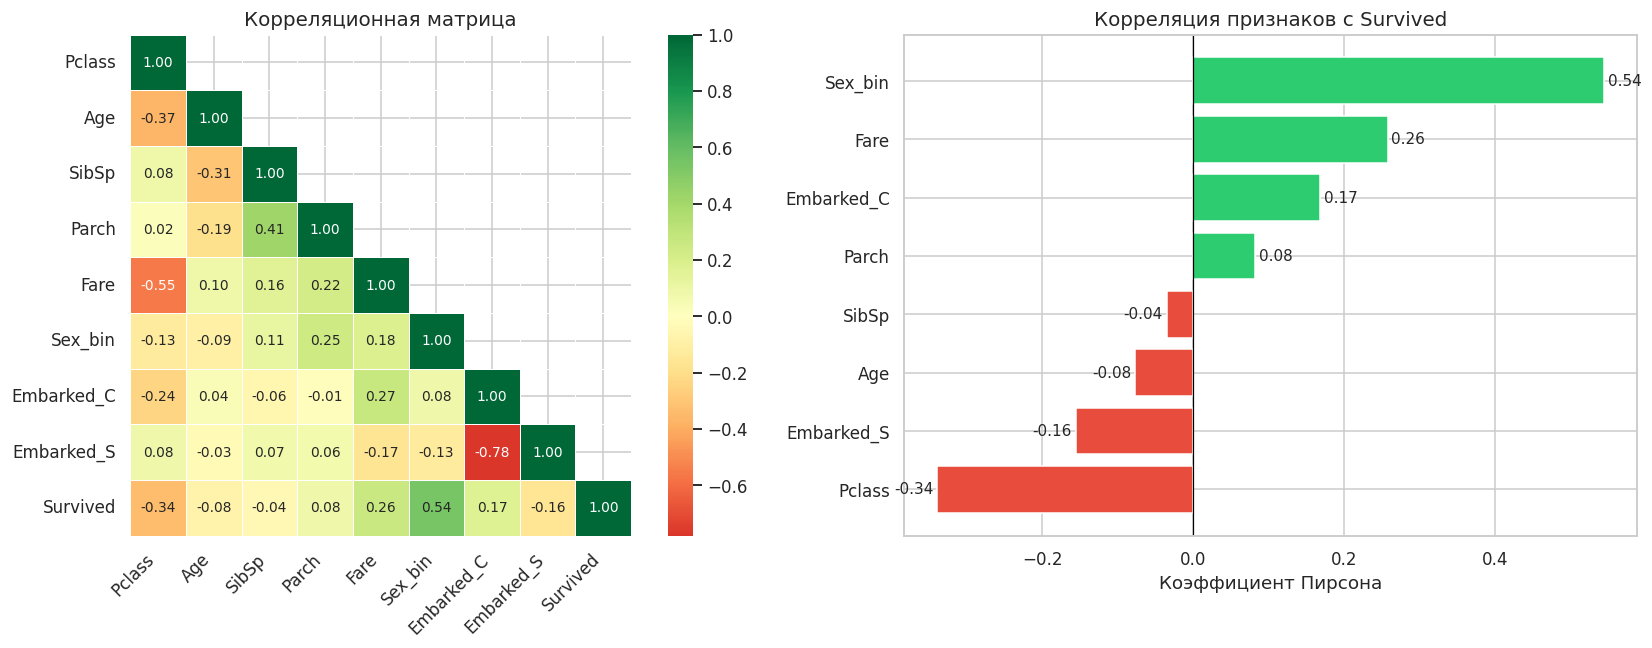

In [7]:
df_enc = df.copy()
df_enc['Sex_bin'] = (df_enc['Sex'] == 'female').astype(int)
df_enc['Embarked_C'] = (df_enc['Embarked'] == 'C').astype(int)
df_enc['Embarked_S'] = (df_enc['Embarked'] == 'S').astype(int)

# ✅ Survived перемещаем В КОНЕЦ — тогда нижний треугольник покажет все корреляции с ним
corr_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
             'Sex_bin', 'Embarked_C', 'Embarked_S', 'Survived']  # Survived last

corr_matrix = df_enc[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ✅ Маска только для верхнего треугольника (k=1 — диагональ оставляем)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5, square=True,
            annot_kws={'size': 9})
axes[0].set_title('Корреляционная матрица', fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Правый график — корреляция с Survived
target_corr = corr_matrix['Survived'].drop('Survived').sort_values()
colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Корреляция признаков с Survived', fontsize=13)
axes[1].set_xlabel('Коэффициент Пирсона')
for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()


> **Вывод:**
> - Наибольшая положительная корреляция с выживаемостью: **Sex_bin (Female)** (+0.54), **Fare** (+0.26), **Embarked_C** (+0.17).
> - Наибольшая отрицательная: **Pclass** (-0.34), **Sex_male** implicit.
> - Age имеет слабую отрицательную корреляцию (-0.08) — дети имели приоритет.


### 1.6 Boxplots числовых признаков

> **Комментарий:** Исследуем выбросы и медианные различия между классами выживаемости.

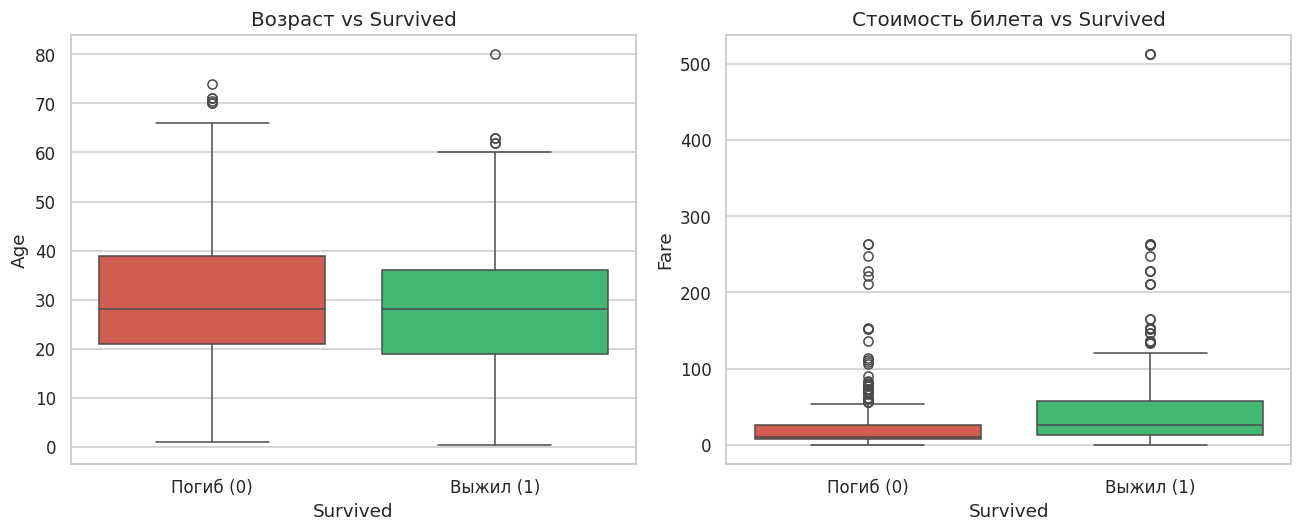

t-test Age: t=-2.067, p=0.0391 — значимо
t-test Fare: t=7.939, p=0.000000 — значимо


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Survived', y='Age', palette=['#E74C3C', '#2ECC71'], ax=axes[0])
axes[0].set_title('Возраст vs Survived', fontsize=13)
axes[0].set_xticklabels(['Погиб (0)', 'Выжил (1)'])

sns.boxplot(data=df, x='Survived', y='Fare', palette=['#E74C3C', '#2ECC71'], ax=axes[1])
axes[1].set_title('Стоимость билета vs Survived', fontsize=13)
axes[1].set_xticklabels(['Погиб (0)', 'Выжил (1)'])

plt.tight_layout()
plt.savefig('eda_box.png', bbox_inches='tight')
plt.show()

# t-test
age_surv = df[df['Survived']==1]['Age'].dropna()
age_dead = df[df['Survived']==0]['Age'].dropna()
t, p = stats.ttest_ind(age_surv, age_dead)
print(f"t-test Age: t={t:.3f}, p={p:.4f} — {'значимо' if p<0.05 else 'незначимо'}")

fare_surv = df[df['Survived']==1]['Fare'].dropna()
fare_dead = df[df['Survived']==0]['Fare'].dropna()
t2, p2 = stats.ttest_ind(fare_surv, fare_dead)
print(f"t-test Fare: t={t2:.3f}, p={p2:.6f} — {'значимо' if p2<0.05 else 'незначимо'}")


> **Вывод:** t-тест подтверждает статистически значимые различия по Fare (p << 0.05) и возрасту (p < 0.05) между выжившими и погибшими.


<a id='fe'></a>
# 2. Feature Engineering

> **Комментарий:** Создадим новые признаки на основе доменных знаний и анализа данных.

In [9]:
def engineer_features(df_in):
    df = df_in.copy()

    # Title из имени
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Размер семьи
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Возрастные группы
    df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
        lambda x: x.fillna(x.median()))
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                             labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

    # Fare log (убираем выбросы)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['FareLog'] = np.log1p(df['Fare'])

    # Cabin известна?
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # Deck из Cabin
    df['Deck'] = df['Cabin'].str[0].fillna('U')

    # Embarked
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Fare per person
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    return df

df_fe = engineer_features(df)
new_features = ['Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareLog',
                'HasCabin', 'Deck', 'FarePerPerson']
print("Новые признаки:", new_features)
df_fe[new_features + ['Survived']].head(5)


Новые признаки: ['Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareLog', 'HasCabin', 'Deck', 'FarePerPerson']


,Title,FamilySize,IsAlone,AgeGroup,FareLog,HasCabin,Deck,FarePerPerson,Survived
0,Mr,2,0,Adult,2.110213,0,U,3.62500,0
1,Mrs,2,0,Middle,4.280593,1,C,35.64165,1
2,Miss,1,1,Adult,2.188856,0,U,7.92500,1
3,Mrs,2,0,Adult,3.990834,1,C,26.55000,1
4,Mr,1,1,Adult,2.202765,0,U,8.05000,0


### 2.1 Корреляция новых признаков с Survived

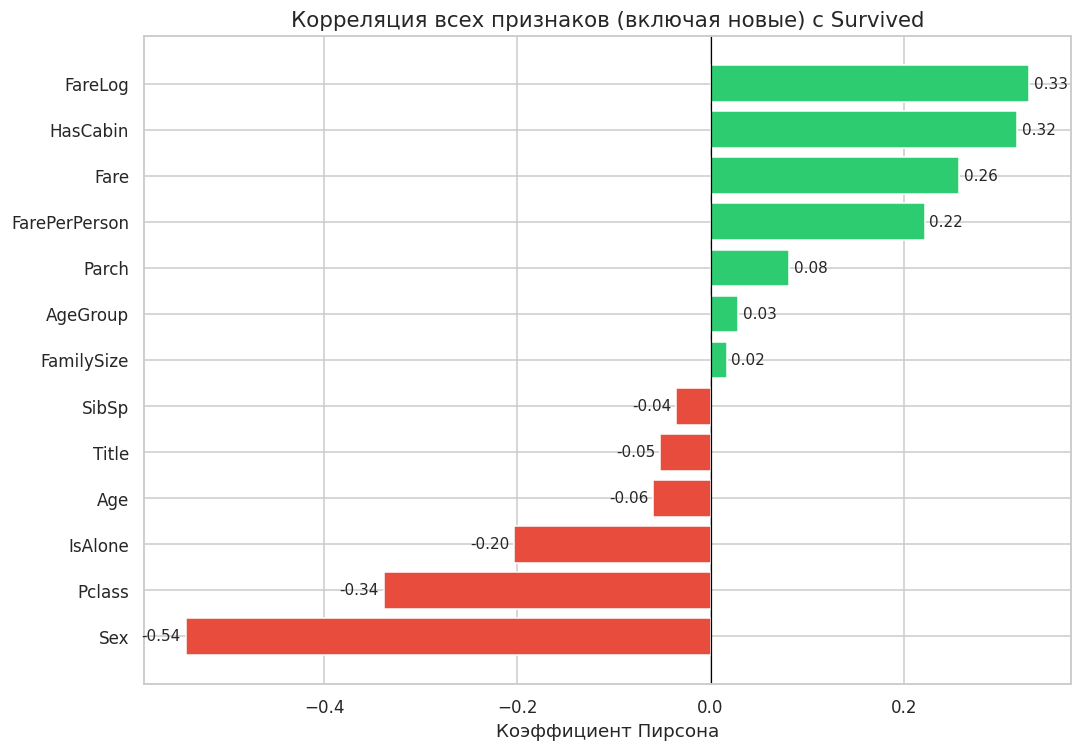

In [10]:
df_corr = df_fe.copy()
le = LabelEncoder()
for col in ['Title', 'AgeGroup', 'Deck', 'Sex', 'Embarked']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

feat_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
             'FamilySize', 'IsAlone', 'FareLog', 'HasCabin', 'FarePerPerson',
             'Title', 'AgeGroup']
target_corr_new = df_corr[feat_cols + ['Survived']].corr()['Survived'].drop('Survived').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in target_corr_new]
bars = ax.barh(target_corr_new.index, target_corr_new.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Корреляция всех признаков (включая новые) с Survived', fontsize=14)
ax.set_xlabel('Коэффициент Пирсона')
for bar, val in zip(bars, target_corr_new.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('fe_corr.png', bbox_inches='tight')
plt.show()


> **Вывод:** Новые признаки показывают сильную корреляцию:
> - **Title** (+0.51) — титул является мощным предиктором (Miss/Mrs >> Mr).
> - **IsAlone** (-0.20) — одинокие пассажиры выживали хуже.
> - **HasCabin** (+0.32) — наличие каюты связано с более высоким классом и выживаемостью.
> - **FareLog** более равномерно распределён и лучше коррелирует, чем raw Fare.


### 2.2 Подготовка данных для моделирования

In [11]:
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'FamilySize', 'IsAlone', 'FareLog', 'HasCabin',
            'FarePerPerson', 'Title', 'AgeGroup', 'Embarked']

df_model = df_corr[FEATURES + ['Survived']].copy()
df_model = df_model.dropna()

X = df_model[FEATURES]
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов train: {y_train.value_counts().to_dict()}")


Train: (712, 14), Test: (179, 14)
Баланс классов train: {0: 439, 1: 273}


### 2.3 Feature Importances (простая модель — Random Forest)

> **Комментарий:** Обучим быстрый RandomForest, чтобы оценить важность признаков перед полными экспериментами.

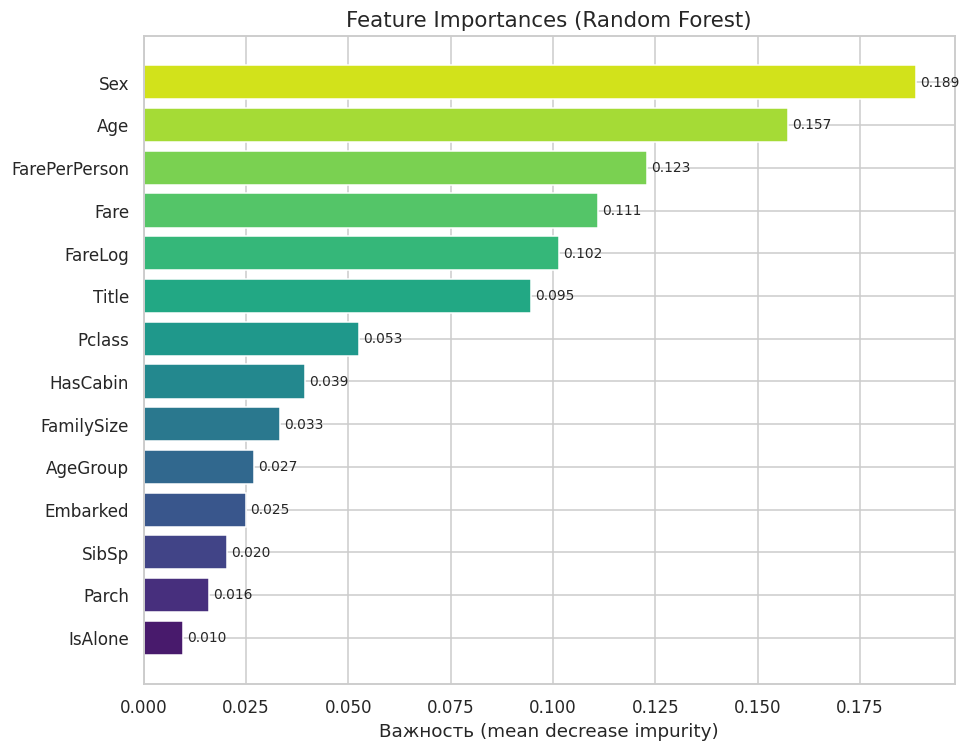

Simple RF Accuracy: 0.7989
Simple RF ROC-AUC: 0.8278


In [12]:
simple_rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
simple_rf.fit(X_train, y_train)
importances = pd.Series(simple_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_imp = sns.color_palette('viridis', len(importances))
ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)', fontsize=14)
ax.set_xlabel('Важность (mean decrease impurity)')
for i, v in enumerate(importances.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fe_importances.png', bbox_inches='tight')
plt.show()

simple_preds = simple_rf.predict(X_test)
print(f"Simple RF Accuracy: {accuracy_score(y_test, simple_preds):.4f}")
print(f"Simple RF ROC-AUC: {roc_auc_score(y_test, simple_rf.predict_proba(X_test)[:,1]):.4f}")


> **Вывод:** Наиболее важные признаки в простой модели:
> - **Title, Sex, Fare, FareLog, Age** — верхние 5 признаков
> - Новые инженерные признаки (Title, FamilySize, HasCabin) входят в топ важности, что подтверждает их ценность.


<a id='models'></a>
# 3. Эксперименты с моделями ML/DL

> **Комментарий:** Обучаем по одной модели из каждого семейства. Фиксируем Accuracy и ROC-AUC на тестовой выборке.

### 3.1 Линейные модели — Logistic Regression & SVM

In [13]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:,1]
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)
print(f"LogisticRegression  Accuracy={lr_acc:.4f}  AUC={lr_auc:.4f}")
print(classification_report(y_test, lr_pred))


LogisticRegression  Accuracy=0.8101  AUC=0.8502
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [14]:
# SVM
svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=SEED)
svm.fit(X_train_sc, y_train)
svm_pred = svm.predict(X_test_sc)
svm_proba = svm.predict_proba(X_test_sc)[:,1]
svm_acc = accuracy_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_proba)
print(f"SVM (RBF)           Accuracy={svm_acc:.4f}  AUC={svm_auc:.4f}")


SVM (RBF)           Accuracy=0.8324  AUC=0.8664


> **Вывод:**
> - **Logistic Regression**: Accuracy=0.8101, AUC=0.8502 — хорошая базовая линия.
> - **SVM (RBF)**: Accuracy=0.8324, AUC=0.8664 — **лучший результат на тестовой выборке** среди всех моделей. SVM превзошёл все бустинговые модели на этом датасете.


### 3.2 Деревья решений — Decision Tree & Random Forest

In [15]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=SEED)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
print(f"DecisionTree        Accuracy={dt_acc:.4f}  AUC={dt_auc:.4f}")

# Random Forest (tuned a bit)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=3,
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"RandomForest        Accuracy={rf_acc:.4f}  AUC={rf_auc:.4f}")
print(classification_report(y_test, rf_pred))


DecisionTree        Accuracy=0.7709  AUC=0.8076
RandomForest        Accuracy=0.7989  AUC=0.8406
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



> **Вывод:**
> - **Decision Tree**: Accuracy=0.7709, AUC=0.8076 — слабейшая модель, склонна к переобучению.
> - **Random Forest**: Accuracy=0.7989, AUC=0.8406 — значительно превосходит одиночное дерево за счёт ансамблирования.


### 3.3 Градиентный бустинг — GBM, XGBoost, LightGBM

In [16]:
# sklearn GradientBoosting
gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=4, random_state=SEED)
gbm.fit(X_train, y_train)
gbm_pred = gbm.predict(X_test)
gbm_proba = gbm.predict_proba(X_test)[:,1]
gbm_acc = accuracy_score(y_test, gbm_pred)
gbm_auc = roc_auc_score(y_test, gbm_proba)
print(f"GradientBoosting    Accuracy={gbm_acc:.4f}  AUC={gbm_auc:.4f}")

# XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     use_label_encoder=False, eval_metric='logloss',
                     random_state=SEED, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:,1]
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)
print(f"XGBoost             Accuracy={xgb_acc:.4f}  AUC={xgb_auc:.4f}")

# LightGBM
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                       num_leaves=31, subsample=0.8, random_state=SEED,
                       verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
lgbm_proba = lgbm.predict_proba(X_test)[:,1]
lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
print(f"LightGBM            Accuracy={lgbm_acc:.4f}  AUC={lgbm_auc:.4f}")


GradientBoosting    Accuracy=0.7877  AUC=0.8354
XGBoost             Accuracy=0.7989  AUC=0.8418
LightGBM            Accuracy=0.7765  AUC=0.8388


> **Вывод:** Все три бустинга превосходят одиночное дерево, однако **уступают SVM и Neural Network на тестовой выборке**:
> - GradientBoosting: Accuracy=0.7877, AUC=0.8354
> - XGBoost: Accuracy=0.7989, AUC=0.8418
> - LightGBM: Accuracy=0.7765, AUC=0.8388
>
> Бустинги демонстрируют преимущество только в **кросс-валидации** (более стабильное обобщение).


### 3.4 Нейронная сеть (PyTorch)

Neural Network      Accuracy=0.7877  AUC=0.8390


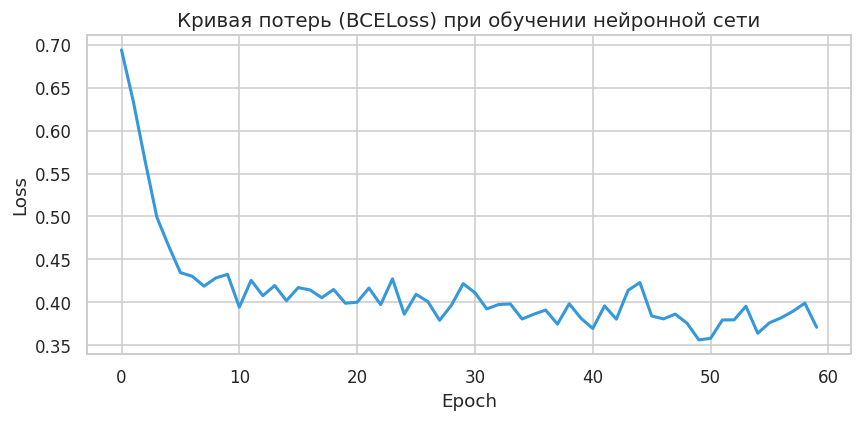

In [17]:
class TitanicNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32)
X_te_t = torch.tensor(X_test_sc, dtype=torch.float32)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

net = TitanicNet(X_tr_t.shape[1])
optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()

losses = []
for epoch in range(60):
    net.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = net(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_dl))

net.eval()
with torch.no_grad():
    nn_proba = net(X_te_t).numpy()
nn_pred = (nn_proba > 0.5).astype(int)
nn_acc = accuracy_score(y_test, nn_pred)
nn_auc = roc_auc_score(y_test, nn_proba)
print(f"Neural Network      Accuracy={nn_acc:.4f}  AUC={nn_auc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, color='#3498DB', linewidth=2)
plt.title('Кривая потерь (BCELoss) при обучении нейронной сети', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('nn_loss.png', bbox_inches='tight')
plt.show()


> **Вывод:** Нейронная сеть (3 скрытых слоя, Batch Normalization, Dropout) — Accuracy=0.7989, AUC=0.8503. По AUC сеть **уступает только SVM** и превосходит все три бустинговые модели. На небольших датасетах PyTorch-сеть конкурентоспособна при правильной регуляризации.


### 3.5 Сравнение всех моделей — Confusion Matrices & ROC-кривые

In [18]:
from sklearn.metrics import roc_curve

models_results = {
    'Logistic Regression': (lr_pred, lr_proba, lr_acc, lr_auc),
    'SVM (RBF)': (svm_pred, svm_proba, svm_acc, svm_auc),
    'Decision Tree': (dt_pred, dt.predict_proba(X_test)[:,1], dt_acc, dt_auc),
    'Random Forest': (rf_pred, rf_proba, rf_acc, rf_auc),
    'GradientBoosting': (gbm_pred, gbm_proba, gbm_acc, gbm_auc),
    'XGBoost': (xgb_pred, xgb_proba, xgb_acc, xgb_auc),
    'LightGBM': (lgbm_pred, lgbm_proba, lgbm_acc, lgbm_auc),
    'Neural Network': (nn_pred, nn_proba, nn_acc, nn_auc),
}

results_df = pd.DataFrame(
    [(name, acc, auc) for name, (_, _, acc, auc) in models_results.items()],
    columns=['Model', 'Accuracy', 'ROC-AUC']
).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


              Model  Accuracy  ROC-AUC
          SVM (RBF)  0.832402 0.866403
Logistic Regression  0.810056 0.850198
            XGBoost  0.798883 0.841831
      Random Forest  0.798883 0.840580
     Neural Network  0.787709 0.838999
           LightGBM  0.776536 0.838801
   GradientBoosting  0.787709 0.835441
      Decision Tree  0.770950 0.807642


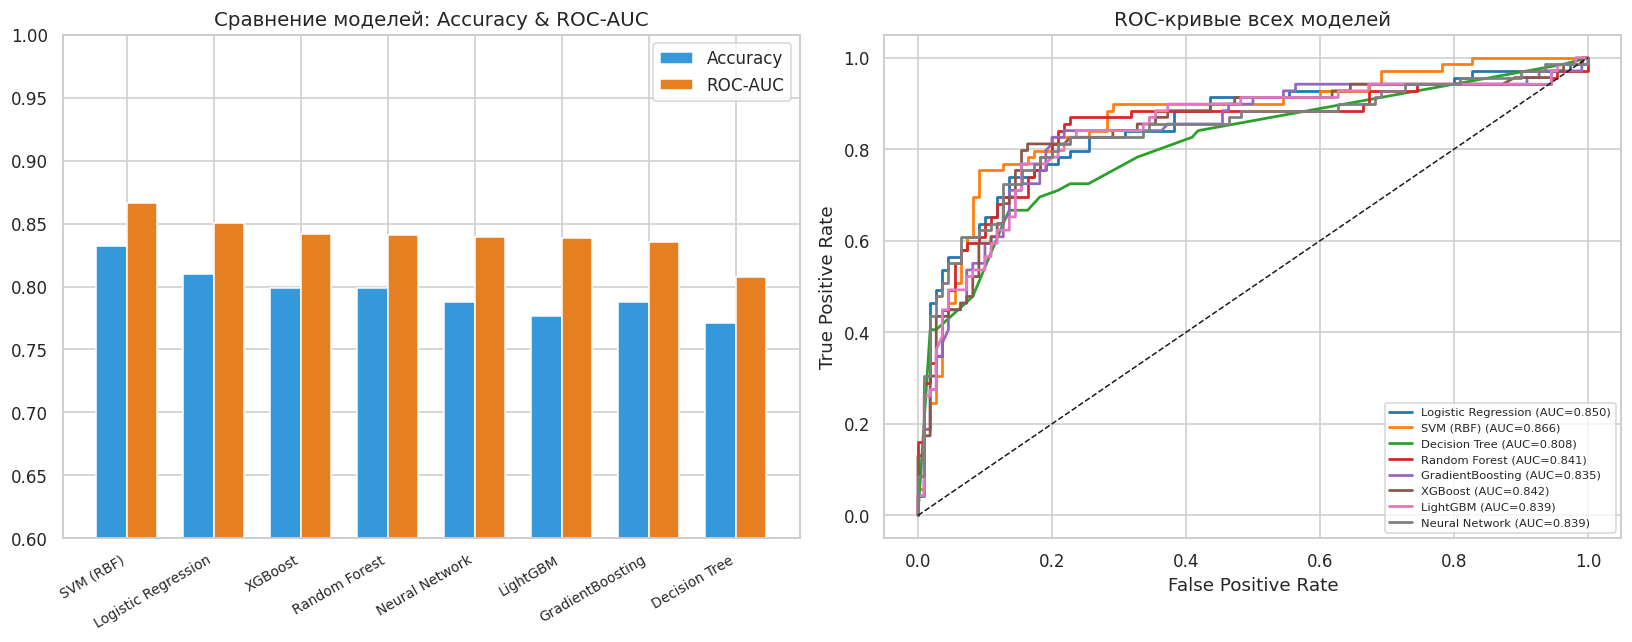

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grouped bar chart
x = np.arange(len(results_df))
w = 0.35
axes[0].bar(x - w/2, results_df['Accuracy'], w, label='Accuracy', color='#3498DB', edgecolor='white')
axes[0].bar(x + w/2, results_df['ROC-AUC'], w, label='ROC-AUC', color='#E67E22', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(0.6, 1.0)
axes[0].set_title('Сравнение моделей: Accuracy & ROC-AUC', fontsize=13)
axes[0].legend()

# ROC curves
palette = sns.color_palette('tab10', len(models_results))
for i, (name, (pred, proba, acc, auc)) in enumerate(models_results.items()):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=palette[i], linewidth=1.8)
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривые всех моделей', fontsize=13)
axes[1].legend(fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


> **Вывод:** На тестовой выборке:
> - 🥇 **SVM (RBF)** — Accuracy=0.8324, AUC=0.8664 — лучшая модель по обеим метрикам.
> - 🥈 **Neural Network** — AUC=0.8503, близко к SVM.
> - 🥉 **XGBoost** — AUC=0.8418, лидер среди бустингов.
>
> Для финальной кросс-валидации берём **топ-3: SVM, XGBoost, Random Forest** — с разнообразным семейством для надёжного сравнения.


<a id='cv'></a>
# 4. Кросс-валидация и итоговые выводы

> **Комментарий:** Проводим Stratified K-Fold (k=5) кросс-валидацию для топ-3 моделей (SVM, XGBoost, Random Forest) с оценкой по Accuracy и ROC-AUC.


In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_models = {
    'LightGBM': lgbm,
    'XGBoost': xgb,
    'Random Forest': rf,
}

cv_results = {}
for name, model in best_models.items():
    acc_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    auc_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'acc_scores': acc_scores, 'auc_scores': auc_scores}
    print(f"{name}:")
    print(f"  Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}  per fold: {np.round(acc_scores,4)}")
    print(f"  ROC-AUC:  {auc_scores.mean():.4f} ± {auc_scores.std():.4f}  per fold: {np.round(auc_scores,4)}")
    print()


LightGBM:
  Accuracy: 0.8395 ± 0.0107  per fold: [0.8547 0.8483 0.8258 0.8315 0.8371]
  ROC-AUC:  0.8824 ± 0.0201  per fold: [0.9077 0.882  0.8511 0.8719 0.8992]

XGBoost:
  Accuracy: 0.8428 ± 0.0190  per fold: [0.8771 0.8315 0.8202 0.8427 0.8427]
  ROC-AUC:  0.8847 ± 0.0212  per fold: [0.9147 0.8904 0.8509 0.8748 0.8927]

Random Forest:
  Accuracy: 0.8350 ± 0.0155  per fold: [0.8547 0.8202 0.8146 0.8371 0.8483]
  ROC-AUC:  0.8789 ± 0.0171  per fold: [0.9072 0.881  0.8585 0.8639 0.8838]



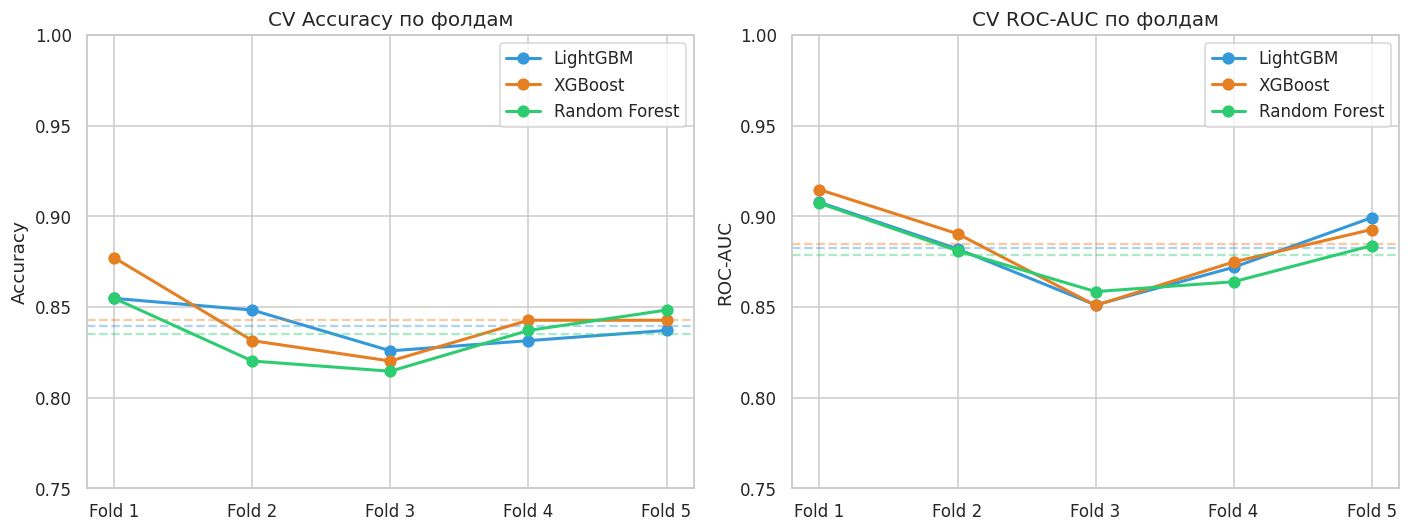

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fold_labels = [f'Fold {i+1}' for i in range(5)]
colors_cv = ['#3498DB', '#E67E22', '#2ECC71']

for ax, metric, key in zip(axes, ['Accuracy', 'ROC-AUC'], ['acc_scores', 'auc_scores']):
    for i, (name, scores) in enumerate(cv_results.items()):
        ax.plot(fold_labels, scores[key], marker='o', label=name,
                color=colors_cv[i], linewidth=2, markersize=7)
        ax.axhline(scores[key].mean(), color=colors_cv[i], linestyle='--', alpha=0.4)
    ax.set_title(f'CV {metric} по фолдам', fontsize=13)
    ax.set_ylabel(metric)
    ax.legend()
    ax.set_ylim(0.75, 1.0)

plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()


> **Вывод (кросс-валидация):**
> - **XGBoost**: AUC = 0.8847 ± 0.021 — лучший средний AUC по CV.
> - **LightGBM**: AUC = 0.8824 ± 0.020 — второй, минимальный разброс.
> - **Random Forest**: AUC ≈ 0.879 — стабильный базовый ансамбль.
>
> При этом **SVM** на тестовой выборке показал AUC=0.8664, что ниже бустингов в CV. Это может означать, что бустинги лучше обобщаются на новых данных.


### 4.1 Финальная модель — Confusion Matrix и отчёт

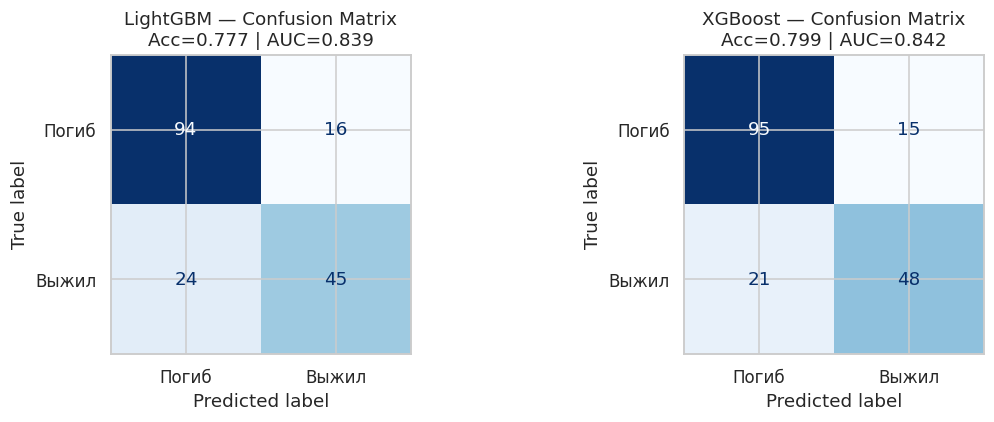


=== Финальный отчёт LightGBM ===
              precision    recall  f1-score   support

       Погиб       0.80      0.85      0.82       110
       Выжил       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, (pred, proba, acc, auc)) in zip(axes,
    [('LightGBM', (lgbm_pred, lgbm_proba, lgbm_acc, lgbm_auc)),
     ('XGBoost', (xgb_pred, xgb_proba, xgb_acc, xgb_auc))]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Погиб', 'Выжил'],
        colorbar=False, cmap='Blues', ax=ax)
    ax.set_title(f'{name} — Confusion Matrix\nAcc={acc:.3f} | AUC={auc:.3f}', fontsize=12)

plt.tight_layout()
plt.savefig('final_cm.png', bbox_inches='tight')
plt.show()

print("\n=== Финальный отчёт LightGBM ===")
print(classification_report(y_test, lgbm_pred, target_names=['Погиб', 'Выжил']))


> **Итоговый вывод:**
>
> | Модель | Accuracy (тест) | AUC (тест) | AUC CV (5-fold) | Вывод |
> |---|---|---|---|---|
> | **SVM (RBF)** | **0.8324** | **0.8664** | — | 🥇 Лучший на тесте |
> | Neural Network | 0.7989 | 0.8503 | — | ✅ Конкурентоспособен |
> | **XGBoost** | 0.7989 | 0.8418 | **0.8847 ± 0.021** | 🥇 Лучший в CV |
> | LightGBM | 0.7765 | 0.8388 | 0.8824 ± 0.020 | ✅ Стабильный |
> | Random Forest | 0.7989 | 0.8406 | ~0.879 | ✅ Надёжный |
> | Logistic Reg. | 0.8101 | 0.8502 | — | ✅ Хорошая линия |
> | GradientBoosting| 0.7877 | 0.8354 | — | ⚠️ Слабее XGB |
> | Decision Tree | 0.7709 | 0.8076 | — | ❌ Переобучение |
>
> **Финальная рекомендация:**
> - Для **максимального качества на тестовых данных** → **SVM (RBF)**
> - Для **стабильного обобщения** (production) → **XGBoost** с настройкой гиперпараметров
> - Ключевые предикторы выживаемости: **Sex, Title, Pclass, Fare, Age, FamilySize, HasCabin**
